# Erosion, Dilation, Opening, and White Top-Hat Transform

In this notebook, we study morphological image processing step by step.

We will see:

1. **Erosion** on a binary image
2. **Dilation** on a binary image
3. **Opening = erosion followed by dilation**
4. **White top-hat transform = original image - opening**

## Main intuition

- **Erosion** shrinks white objects.
- **Dilation** grows white objects.
- **Opening** removes small bright objects while keeping larger structures.
- **White top-hat** extracts the small bright details removed by opening.

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_erosion, binary_dilation, grey_opening, grey_closing

np.set_printoptions(linewidth=120)

def show_binary(img, title):
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap="gray", vmin=0, vmax=1)
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_three(a, b, c, t1, t2, t3, cmap="gray", vmin=None, vmax=None):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, img, title in zip(axes, [a, b, c], [t1, t2, t3]):
        ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

def show_four(a, b, c, d, t1, t2, t3, t4, cmap="gray", vmin=None, vmax=None):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, img, title in zip(axes, [a, b, c, d], [t1, t2, t3, t4]):
        ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

Binary image A:

[[0 0 0 0 0 0 0 0 0]
 [0 0 1 1 1 0 0 0 0]
 [0 0 1 1 1 0 0 1 0]
 [0 0 1 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 1 1 0 0 0 1 1 0]
 [0 1 1 0 0 0 1 1 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]]

Structuring element B:

[[1 1 1]
 [1 1 1]
 [1 1 1]]


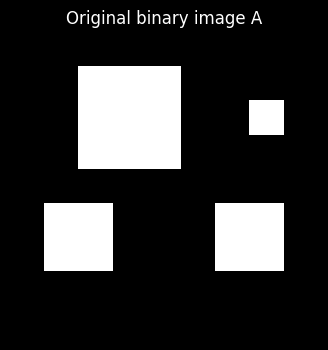

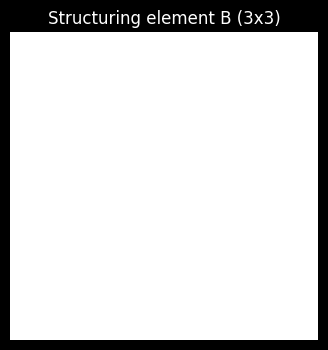

In [27]:
# Binary image: one large block + one small bright pixel
A = np.array([
    [0,0,0,0,0,0,0,0,0],
    [0,0,1,1,1,0,0,0,0],
    [0,0,1,1,1,0,0,1,0],
    [0,0,1,1,1,0,0,0,0],
    [0,0,0,0,0,0,0,0,0],
    [0,1,1,0,0,0,1,1,0],
    [0,1,1,0,0,0,1,1,0],
    [0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0],
], dtype=bool)

B = np.ones((3, 3), dtype=bool)

print("Binary image A:\n")
print(A.astype(int))
print("\nStructuring element B:\n")
print(B.astype(int))

show_binary(A, "Original binary image A")
show_binary(B, "Structuring element B (3x3)")

Eroded image:

[[0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]]


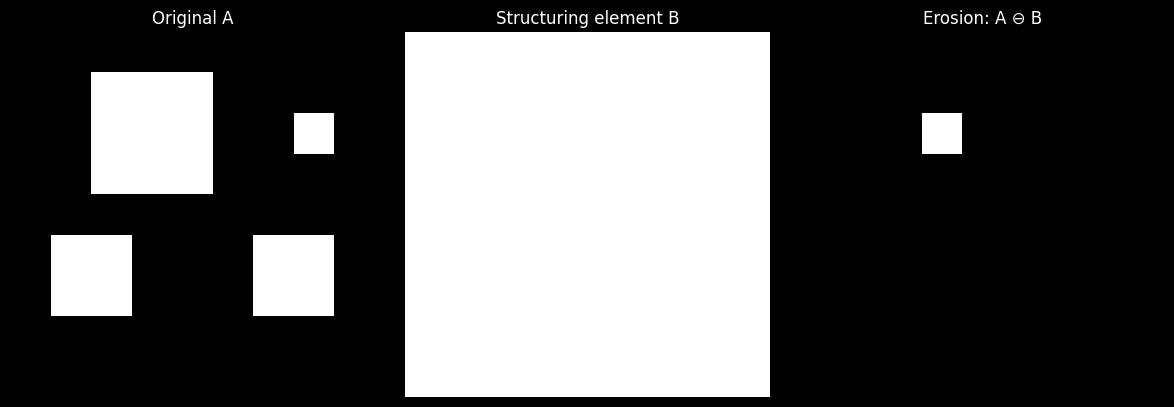

In [28]:
eroded = binary_erosion(A, structure=B)

print("Eroded image:\n")
print(eroded.astype(int))

show_three(
    A, B, eroded,
    "Original A", "Structuring element B", "Erosion: A ⊖ B",
    cmap="gray", vmin=0, vmax=1
)

In [29]:
# Choose a center where erosion should succeed
i, j = 2, 3   # center inside the big 3x3 block

patch = A[i-1:i+2, j-1:j+2].astype(int)
kernel = B.astype(int)
product = patch * kernel

print("Chosen center:", (i, j))
print("\nLocal 3x3 patch:\n")
print(patch)
print("\nKernel B:\n")
print(kernel)
print("\nElementwise product:\n")
print(product)

print("\nSum(product) =", product.sum())
print("Sum(kernel)  =", kernel.sum())

if product.sum() == kernel.sum():
    print("\nErosion output at this pixel = 1")
else:
    print("\nErosion output at this pixel = 0")

Chosen center: (2, 3)

Local 3x3 patch:

[[1 1 1]
 [1 1 1]
 [1 1 1]]

Kernel B:

[[1 1 1]
 [1 1 1]
 [1 1 1]]

Elementwise product:

[[1 1 1]
 [1 1 1]
 [1 1 1]]

Sum(product) = 9
Sum(kernel)  = 9

Erosion output at this pixel = 1


Dilated image:

[[0 1 1 1 1 1 0 0 0]
 [0 1 1 1 1 1 1 1 1]
 [0 1 1 1 1 1 1 1 1]
 [0 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 0 1 1 1 1]
 [1 1 1 1 0 1 1 1 1]
 [1 1 1 1 0 1 1 1 1]
 [0 0 0 0 0 0 0 0 0]]


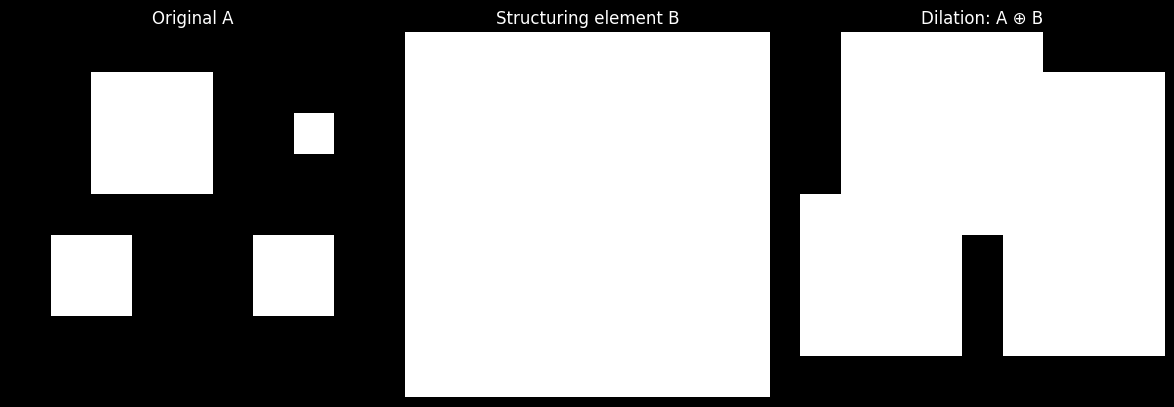

In [30]:
dilated = binary_dilation(A, structure=B)

print("Dilated image:\n")
print(dilated.astype(int))

show_three(
    A, B, dilated,
    "Original A", "Structuring element B", "Dilation: A ⊕ B",
    cmap="gray", vmin=0, vmax=1
)

Opened binary image:

[[0 0 0 0 0 0 0 0 0]
 [0 0 1 1 1 0 0 0 0]
 [0 0 1 1 1 0 0 0 0]
 [0 0 1 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]]


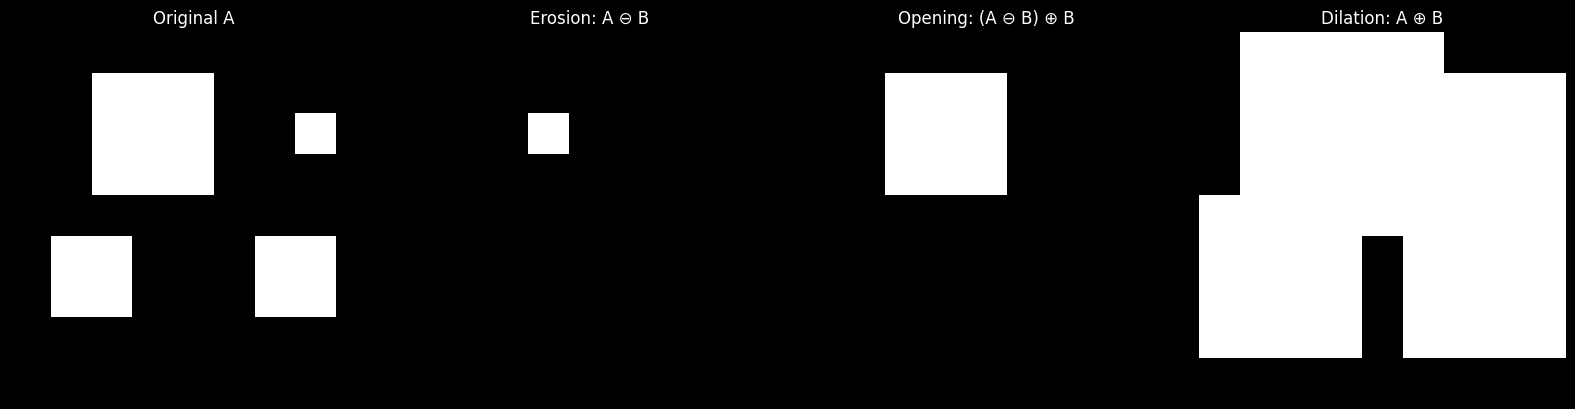

In [31]:
opened_binary = binary_dilation(eroded, structure=B)

print("Opened binary image:\n")
print(opened_binary.astype(int))

show_four(
    A, eroded, opened_binary, dilated,
    "Original A",
    "Erosion: A ⊖ B",
    "Opening: (A ⊖ B) ⊕ B",
    "Dilation: A ⊕ B",
    cmap="gray", vmin=0, vmax=1
)

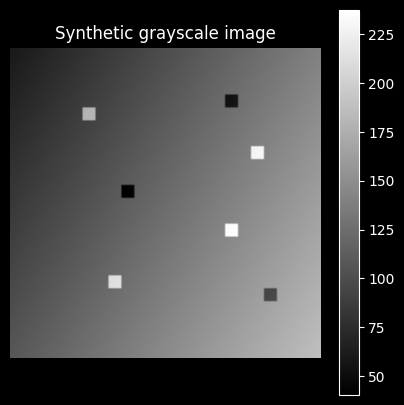

In [32]:
# Synthetic grayscale image
n = 120
x = np.linspace(0, 1, n)
X, Y = np.meshgrid(x, x)

# Smooth varying background
background = 60 + 80 * (X + 0.6 * Y)

# Add small bright spots
img = background.copy()
spots = [(25, 30), (70, 85), (90, 40), (40, 95)]
for r, c in spots:
    img[r-2:r+3, c-2:c+3] += 90

# Add small dark spots so black top-hat has meaningful structures to extract
dark_spots = [(20, 85), (55, 45), (95, 100)]
for r, c in dark_spots:
    img[r-2:r+3, c-2:c+3] -= 70

img = np.clip(img, 0, 255)

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.title("Synthetic grayscale image")
plt.axis("off")
plt.colorbar()
plt.show()

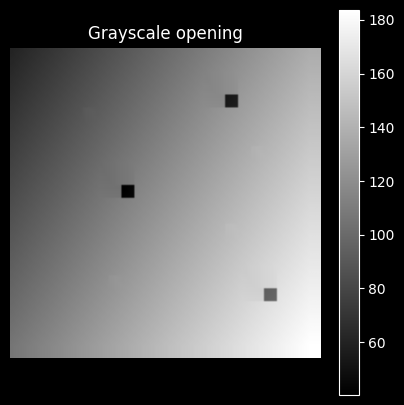

In [33]:
# 9x9 structuring element for grayscale opening
structure = np.ones((9, 9))

opened_gray = grey_opening(img, footprint=structure)

plt.figure(figsize=(5, 5))
plt.imshow(opened_gray, cmap="gray")
plt.title("Grayscale opening")
plt.axis("off")
plt.colorbar()
plt.show()

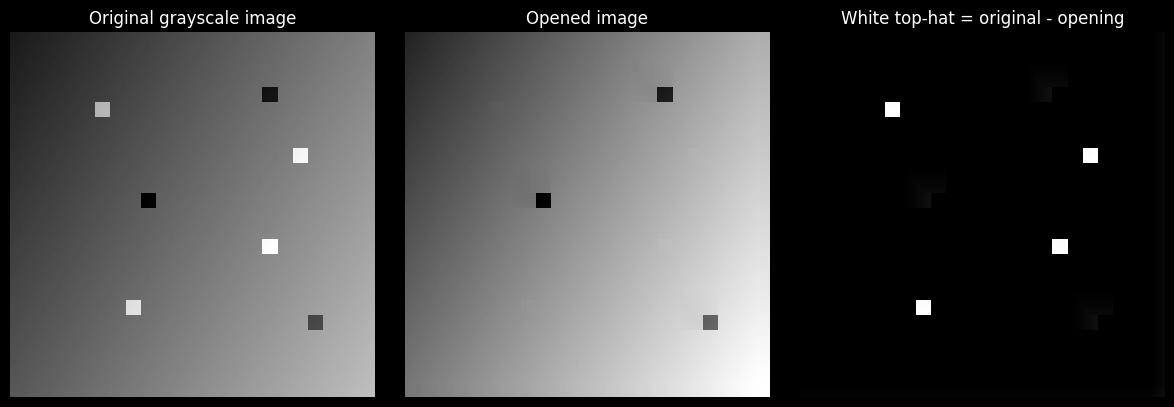

In [34]:
white_tophat = img - opened_gray

show_three(
    img, opened_gray, white_tophat,
    "Original grayscale image",
    "Opened image",
    "White top-hat = original - opening",
    cmap="gray"
)

In [ ]:
closed_gray = grey_closing(img, footprint=structure)
black_tophat = closed_gray - img

show_three(
    img, closed_gray, black_tophat,
    "Original grayscale image",
    "Closed image",
    "Black top-hat = closing - original",
    cmap="gray"
)

## Conclusion: why use white top-hat and black top-hat?

- **White top-hat** is useful when we want to extract **small bright details** that stand out from a slowly varying background.
  Typical examples are bright particles, highlights, small defects, or tiny blobs.

- **Black top-hat** is useful when we want to extract **small dark details** that are darker than their neighborhood.
  Typical examples are dark pits, thin cracks, dark spots, or small shadows.

In practice, these two transforms help us separate **local details** from the **large-scale background illumination**.
So they are often used as a simple preprocessing step for **detection, enhancement, and segmentation**.
